# Exploratory Data Analysis

**Roles to Explore:**

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# loading Data 
from datasets import  load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()



In [2]:
# cleaning data frame
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [48]:
# df['job_title_short'].unique() 
# df.info() 

# Filter for US Data Scientist

In [8]:
df_US_DS = df[(df['job_country'] == "United States") &(df['job_title_short'] == 'Data Scientist') ]

**Number of  Data Scientist Job per Job Location for **

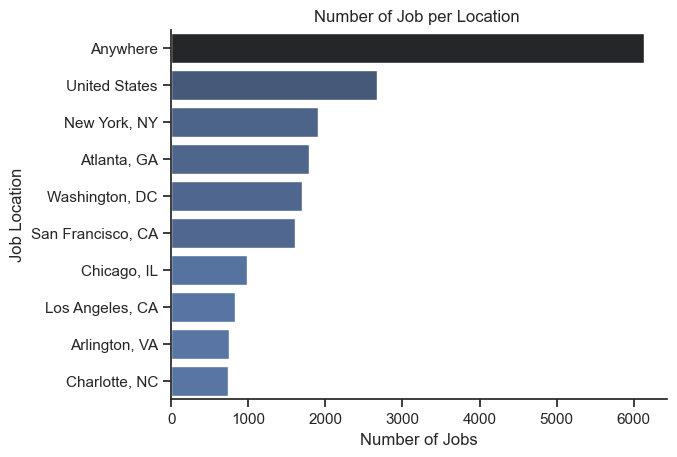

In [29]:
df_plot =df_US_DS['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data =df_plot,x='count',y='job_location',hue='count' ,palette="dark:b_r",legend = False )
sns.despine()
plt.title("Number of Job per Location ")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Location")
# ax = plt.gca()
# # ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f"${int(x/1000)}k"))
# ax.legend().remove()
plt.show()



<!-- Work from / Dgree Required/ Health Insurance Offered -->
***Benifit Analysis of Data Scientist Jobs***

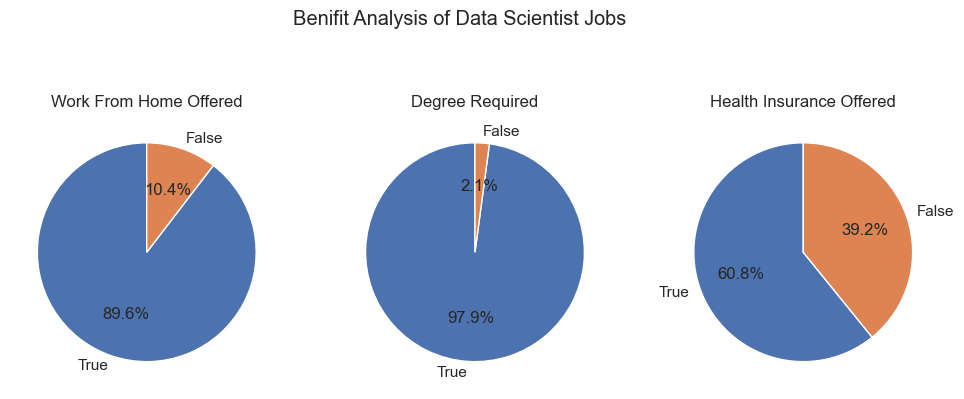

In [37]:
dict_column = {
    'job_work_from_home':"Work From Home Offered",
    'job_no_degree_mention':"Degree Required",
    'job_health_insurance':"Health Insurance Offered"
}
fig ,ax = plt.subplots(1,3)
fig.set_size_inches(12,5)
for i ,(column,title) in enumerate(dict_column.items()):
    ax[i].pie(df_US_DS[column].value_counts(),labels=['True','False'],autopct ='%1.1f%%',startangle = 90)
    ax[i].set_title(title)
plt.suptitle('Benifit Analysis of Data Scientist Jobs')
plt.show()

**Number of  Data Scientist Job  as per Top Company **

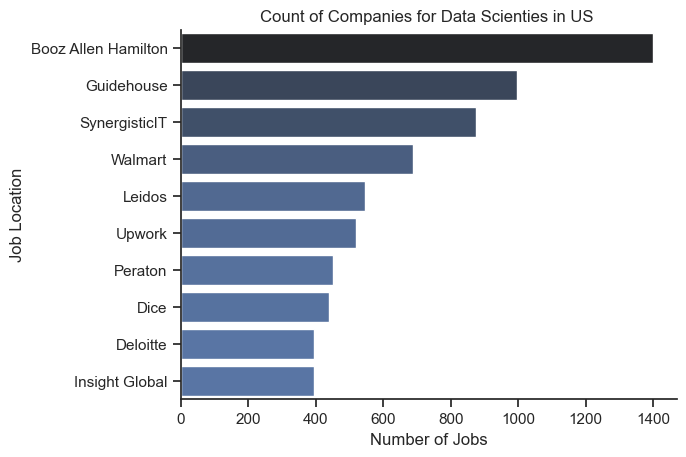

In [47]:
df_plot = df_US_DS['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style="ticks")
sns.barplot(data = df_plot , x = 'count' , y = 'company_name',hue = 'count',palette ='dark:b_r',legend = False)
sns.despine()
plt.title("Count of Companies for Data Scienties in US ")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Location")
plt.show()